In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.integrate import quad
from scipy.interpolate import interp1d
import pandas as pd
import sympy as sy
from scipy.misc import derivative
import csv
import os

### Notes: 
1. If you remove 'SF' from term2 of calculate_Eprime_RS(), you will get a conventional stress relaxation curve. The WLF shift factor (SF) is inverted due to a temperature which is starting high and decreasing, making the modulus increase over time. However, once it reaches thermal equilibrium with its surroundings (T=298K), you can see the more conventional relaxation behavior.

2. BLOCK 1 and BLOCK 2 offer two ways to calculate storage modulus: relaxation spectra and Prony series. Relaxation spectrum and Prony series values are generated in supporting script (relaxation_spectrum.ipynb) using DMA data.

3. Function *calculate_alpha()* in BLOCK 2 and *calculate_alpha_simple()* in BLOCK 7 are currently hard-coded to evaluate WLF shift factor $\alpha_T$ at 310K. 

### Supporting Scripts:
./git/bistable_phrozen/relaxation_spectrum.ipynb \
./git/bistable_phrozen/DMA_analysis.ipynb\
./git/bistable_phrozen/WLF_symbolic.ipynb

### BLOCK 1: User-Defined Parameters and Functions

In [11]:
# Thermal properties and initial conditions
t_end    = 10000.0
t        = np.linspace(0.0,t_end,1000)
T0       = 423             # Initial temperature, K
Tref     = 273             # Reference temperature for CTE, K
Tinf     = 298             # Ambient temperature
Thot     = 423             # Temperature to which entire part is heated
T_ref_MC = 363             # Reference temperature for master curve and WLF shifting, K
cp       = 1.4E9           # specific heat, mJ/(tonne*K)
k        = 0.16            # thermal conductivity, mW/(mm*K)
rho      = 1.1E-9          # density, tonne/mm^3
CTE      = np.array([[273,423],[600E-6,600E-6]])          # CTE (temperature-independent), 1/K 
#CTE      = np.array([[273,303,308,473],[300E-6,300E-6,600E-6,600E-6]]) # Array of [CTE,Temp]
h        = 0.001           # convective heat transfer coefficient, mW/(mm^2*K)

# Relaxation spectrum parameters (using master curve generated at Tref=90C) and other viscoelastic parameters
nu_g      = 0.34         # glassy Poisson's ratio
nu_r      = 0.5          # rubbery Poisson's ratio
tau_visco = 10**-4       # characteristic relaxation time, s
E0        = 1587.7       # MPa 
E_eq      = 6.56         # MPa
mu_eq     = E_eq/(2 * (1 + nu_r))
tau_k     = [9E10,5.99E9,3.95E8,2.61E7,1.72E6,1.13E5,7.49E3,4.94E2,3.26E1,2.15,1.42E-1,9.36E-3]     # relaxation time constants, s
mu_neqk   = [1.36,4.399,19.5,38.7,48.4,47.2,54.5,65.7,72.8,78.8,103,55.6]                           # non-equilibrium modulii, MPa

# Read in Prony terms (e_i,k_i,tau_i)
prony_terms = pd.read_csv('/Users/mikelapera/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/JHU/Research/Experiments/DMA/data/Phrozen/Phrozen_prony_series_20_Tref90C.csv',header=None)
gi          = prony_terms[0]
ki          = prony_terms[1]
tau_i       = prony_terms[2]
#  Convert to shear storage modulus (IAW Abaqus formulation)
ei          = list(gi * (2.0 * (1.0 + nu_g)))
tau_i       = list(tau_i)

# WLF Shift Parameters (previously determined)
C1          = 22.84  # WLF shift factor parameter 
C2          = 214.44 # WLF shift factor parameter


# Lumped capacitance model to calculate temperature, T(t)
def calculateT(T0,Tinf,tau_c,t):
    T = (T0 - Tinf)*np.exp(-t/tau_c) + Tinf
    return T

# Calculate CTE value at given temperature
def calculate_CTE(T):
    CTE_val = np.interp(T,CTE[0],CTE[1])
    return CTE_val 

# WLF Shift factor equation
def calculate_alpha(C1,C2,T0,T_ref_MC,tau_c,t,T):
    T = calculateT(T0,Tinf,tau_c,t)
    #SF    = 10**((-C1*(T-T_ref_MC))/(C2+T-T_ref_MC))
    # This overwrites the previously calculated SF and assumes a constant alpha_T @ T=310K for simplicity
    #T     = 310
    SF    = 10**((-C1*(310-T_ref_MC))/(C2+310-T_ref_MC))
    #SF    = T * 0 + 1
    return SF

# Calculate relaxation modulus using relaxation spectrum method
def calculate_Eprime_RS(C1,C2,tau_c,E_eq,tau_k,mu_neqk,nu_g,nu_r,t,T_col):
    Ep    = []
    SF    = calculate_alpha(C1,C2,T0,Tref,tau_c,t,T_col)
    # See Eq. 34 Overleaf doc
    term1 = 3 * mu_eq
    term2 = sum(2.7 * mu_neqk[k] * np.exp(-t/(SF*tau_k[k])) for k in range(0,len(tau_k)))
    Ep    = term1 + term2
    return Ep

# Calculate relaxation modulus using Prony series approximation
def calculate_Eprime_PS(C1,C2,tau_c,E0,tau_i,ei,t,T_col):
    Ep    = []
    SF    = calculate_alpha(C1,C2,T0,T_ref_MC,tau_c,t,T_col)
    Ep    = E0 * (1 - sum(ei[k] * (1 - np.exp(-t/(SF*tau_i[k]))) for k in range(0,len(tau_i))))

    return Ep

# Calculate thermally-driven buckling load (relaxation spectrum, viscoelastic case)
def Pthermal_RS(A,C1,C2,t,T0,Tinf,tau_c_col,tau_c_frame):
    T_col     = (T0-Tinf) * (np.exp(-t/tau_c_col)) + Tinf
    T_frame   = (T0-Tinf) * (np.exp(-t/tau_c_frame)) + Tinf    
    SF        = calculate_alpha(C1,C2,T0,Tref,tau_c_col,t,T_col)
    Ep        = calculate_Eprime_RS(C1,C2,tau_c_col,E_eq,tau_k,mu_neqk,nu_g,nu_r,t,T_col)

    CTE_frame = calculate_CTE(T_frame)
    CTE_col   = calculate_CTE(T_col)
    # See Overleaf doc Eq. 14
    Pth       = A * Ep * (CTE_frame * T_frame - CTE_col * T_col)
    return Pth,SF,Ep

# Calculate critical buckling load (relaxation spectrum, viscoelastic case)
def Pcritical_RS(T0,Tinf,Tref,Icol,kc,Lcol,tau_c_frame,t):
    T_col     = (T0-Tinf) * (np.exp(-t/tau_c_col)) + Tinf
    T_frame   = (T0-Tinf) * (np.exp(-t/tau_c_frame)) + Tinf
    SF        = calculate_alpha(C1,C2,T0,Tref,tau_c_col,t,T_col)
    Ep        = calculate_Eprime_RS(C1,C2,tau_c_col,E_eq,tau_k,mu_neqk,nu_g,nu_r,t,T_col)

    CTE_frame = calculate_CTE(T_frame)
    CTE_col   = calculate_CTE(T_col)
    Leff      = kc * (Lcol + CTE_frame * (np.exp(-t/tau_c_frame)*(T0-Tinf) + Tinf - Tref))
    Pcr       = -1 * (np.pi**2 * Ep * Icol) / (Leff**2)
    return Pcr,SF,Ep


# Calculate thermally-driven buckling load (Prony series, viscoelastic case)
def Pthermal_PS(A,C1,C2,t,T0,Tinf,tau_c_col,tau_c_frame):
    T_col     = (T0-Tinf) * (np.exp(-t/tau_c_col)) + Tinf
    T_frame   = (T0-Tinf) * (np.exp(-t/tau_c_frame)) + Tinf
    SF        = calculate_alpha(C1,C2,T0,Tref,tau_c_col,t,T_col)
    Ep        = calculate_Eprime_PS(C1,C2,tau_c_col,E0,tau_i,ei,t,T_col)

    CTE_frame = calculate_CTE(T_frame)
    CTE_col   = calculate_CTE(T_col)
    Pth       =  A * Ep * (CTE_frame * T_frame - CTE_col * T_col)
    return Pth,SF,Ep

# Calculate critical buckling load (Prony series, viscoelastic case)
def Pcritical_PS(T0,Tinf,Tref,Icol,kc,Lcol,tau_c_frame,t):
    T_col     = (T0-Tinf) * (np.exp(-t/tau_c_col)) + Tinf
    T_frame   = (T0-Tinf) * (np.exp(-t/tau_c_frame)) + Tinf

    SF        = calculate_alpha(C1,C2,T0,Tref,tau_c_col,t,T_col)
    Ep        = calculate_Eprime_PS(C1,C2,tau_c_col,E0,tau_i,ei,t,T_col)

    CTE_frame = calculate_CTE(T_frame)
    CTE_col   = calculate_CTE(T_col)
    Leff      = kc * (Lcol + CTE_frame * (np.exp(-t/tau_c_frame)*(T0-Tinf) + Tinf - Tref))
    Pcr       = -1 * (np.pi**2 * Ep * Icol) / (Leff**2)
    return Pcr,SF,Ep

# Calculate thermal strain
def calculate_eps_thermal(T,Tinf,tau_c):
    T           = (T0-Tinf) * (np.exp(-t/tau_c)) + Tinf
    CTE         = calculate_CTE(T)
    eps_thermal = CTE * (T-Tref)
    return eps_thermal

# Calculate buckling crossover plot overlap
def overlap(Pth):
    # Take absolute value for log-plotting (value is negative naturally due to thermal contraction of part)
    Pth = abs(Pth)

    # Find time domain and Pth values which exceed theoretical buckling value
    fcrit = np.asarray(sorted(i for i in Pth if i >= np.mean(Pcr))) #using mean for simplicity - all values in Pcr are nearly identical

    # Locate overlap by sorting where Pth > Pcrit
    sorter = np.argsort(Pth)
    idx = sorter[np.searchsorted(Pth, fcrit, sorter=sorter)]
    plt.loglog(t[idx],Pth[idx],'*')
    plt.grid(which='both')
    plt.xlabel('Time (s)')
    plt.ylabel('Engineering Stress (MPa)')
    eta_approx = trapezoid(Pth[idx])
    print(eta_approx)
    return eta_approx

# Column dimensions
tcol        = 5                       # out-of-plane thickness, mm
wcol        = 0.5                     # in-plane thickness, mm
Icol        = (1/12) * tcol * wcol**3 # Area moment of inertia of column, mm^4
Lcol        = 50                      # initial column length at T0, mm
kc          = 0.5                     # Euler buckling BC correction
Vcol        = tcol*wcol*Lcol          # column volume, mm^3
m_col       = rho * Vcol              # column mass, tonne
A_col       = tcol * wcol             # column cross-sectional area
Asurf_col   = 2 * wcol * Lcol + 2 * tcol * Lcol # column surface area, mm^2
tau_c_col   = (m_col*cp)/(h*Asurf_col)          # characteristic cooling time of column, s

# Frame dimensions (single, vertical side)
tf          = 5                         # out-of-plane thickness, mm
wf          = 5                         # in-plane thickness, mm
Lf          = Lcol                      # initial column length at T0, mm
Vf          = tf*wf*Lf                  # frame volume, mm^3
m_f         = rho * Vf                  # frame mass, tonne
Asurf_f     = 2 * wf * Lf + 2 * tf * Lf # frame surface area, mm^2
tau_c_frame = (m_f*cp)/(h*Asurf_f)

# Calculate thermally-driven and critical buckling loads
#Pth,SF,Ep_col   = Pthermal_RS(A_col,C1,C2,t,T0,Tinf,tau_c_col,tau_c_frame)
#Pcr,SF,Ep_frame = Pcritical_RS(T0,Tinf,Tref,Icol,k,Lcol,tau_c_frame,t)

Pth,SF,Ep_col   = Pthermal_PS(A_col,C1,C2,t,T0,Tinf,tau_c_col,tau_c_frame)
Pcr,_,_         = Pcritical_PS(T0,Tinf,Tref,Icol,kc,Lcol,tau_c_frame,t)

### BLOCK 2: Plot column and frame cooling profiles

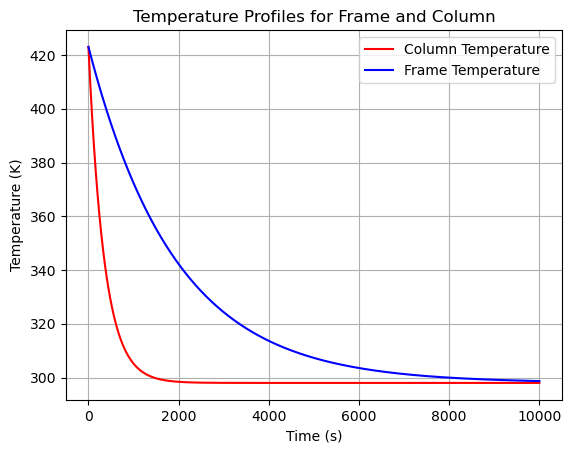

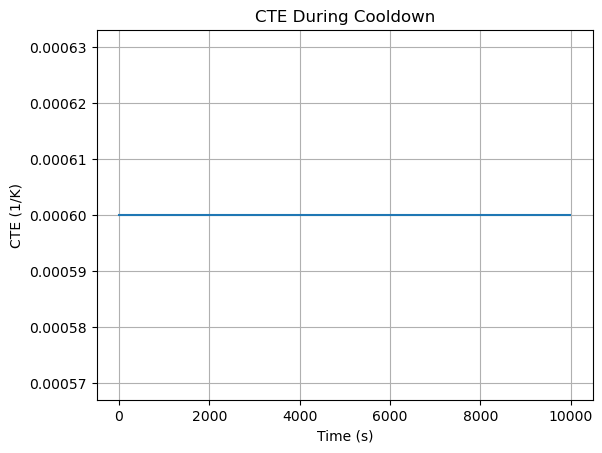

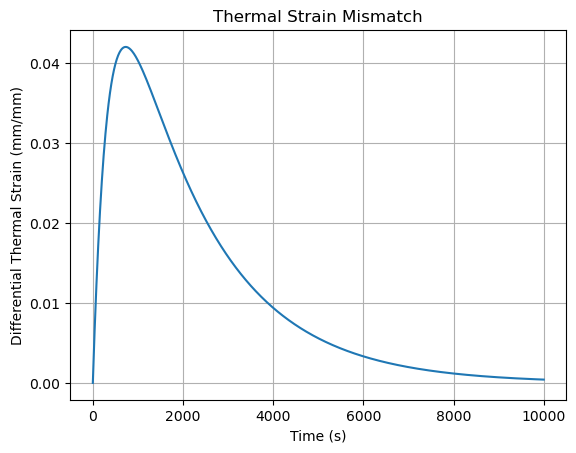

In [12]:
# Calculate temperature profiles for frame and column
Tcol         = calculateT(T0,Tinf,tau_c_col,t)
Tframe       = calculateT(T0,Tinf,tau_c_frame,t)

# Calculate thermal strains for frame and column
eps_th_frame = calculate_eps_thermal(Tframe,Tinf,tau_c_frame)
eps_th_col   = calculate_eps_thermal(Tcol,Tinf,tau_c_col)

# Calculate thermal strain mismatch
delta_eps_th = eps_th_frame - eps_th_col

# Plotting
plt.plot(t,Tcol,'-r',t,Tframe,'-b')
plt.title('Temperature Profiles for Frame and Column')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)')
plt.legend(['Column Temperature','Frame Temperature'])
plt.savefig('Tcol_vs_Tframe.svg')
plt.savefig('Tcol_vs_Tframe.png')
plt.show()
plt.figure()
plt.plot(t[1:-1],calculate_CTE(Tcol)[1:-1])
plt.title('CTE During Cooldown')
plt.xlabel('Time (s)')
plt.ylabel('CTE (1/K)')
plt.grid(which='both')
plt.figure()
plt.plot(t,delta_eps_th)
plt.title('Thermal Strain Mismatch')
plt.xlabel('Time (s)')
plt.ylabel('Differential Thermal Strain (mm/mm)')
plt.grid(which='both')
plt.savefig('thermal_strain_mismatch.svg')
plt.savefig('thermal_strain_mismatch.png')
plt.show()

### BLOCK 3: Plot storage modulus vs. time (assuming a constant alpha_T @ 310K - See Note 3)

<Figure size 640x480 with 0 Axes>

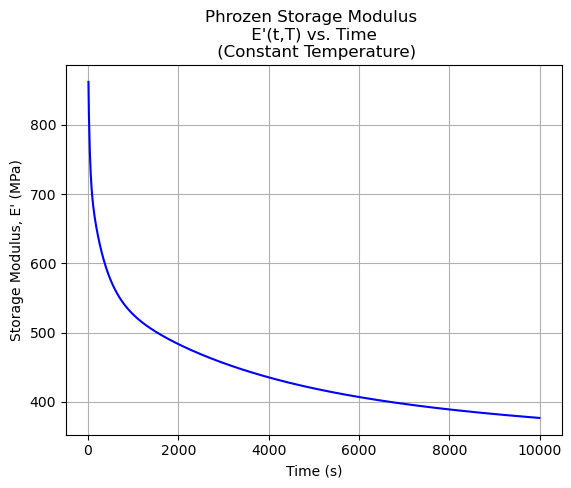

<Figure size 640x480 with 0 Axes>

In [13]:
plt.plot(t[1:-1],Ep_col[1:-1],'-b')
plt.title("Phrozen Storage Modulus \n E'(t,T) vs. Time \n (Constant Temperature)")
plt.xlabel('Time (s)')
plt.ylabel("Storage Modulus, E' (MPa)")
plt.grid(which='both')
plt.figure()

### BLOCK 4: Plot thermally-induced axial force and critical buckling force as a function of time

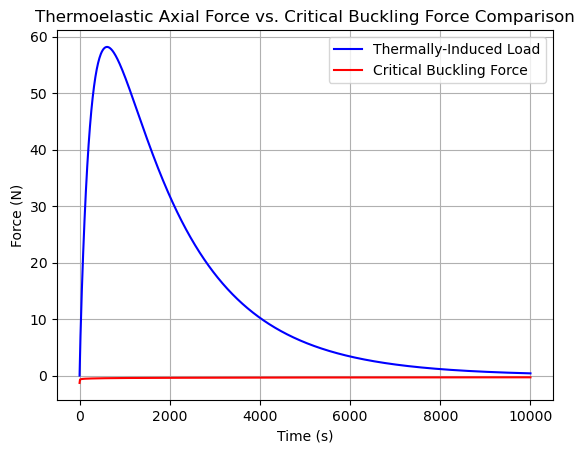

In [14]:
plt.plot(t,Pth,'-b',t,Pcr,'-r')
plt.title('Thermoelastic Axial Force vs. Critical Buckling Force Comparison')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.grid(which='both')
plt.legend(['Thermally-Induced Load','Critical Buckling Force'])
plt.savefig('Pth_vs_Pcr_thermoelastic.svg')
plt.savefig('Pth_vs_Pcr_thermoelastic.png')

### BLOCK 5: 1D Solution - Standard Linear Solid
This approach is taken from Ch. 6 of Bergstrom's Mechanics of Solid Polymers textbook. The intention is to determine whether or not compressive stress can occur given the intrinsic relaxation behavior of the material and the applied strain history

In [6]:
# Read in Prony terms (e_i,k_i,tau_i)
# prony_terms = pd.read_csv('/Users/mikelapera/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/JHU/Research/Experiments/DMA/data/Phrozen/Phrozen_prony_series_20_Tref90C.csv',header=None)
# gi          = prony_terms[0]
# ki          = prony_terms[1]
# tau_i       = prony_terms[2]
# # Convert to shear storage modulus (IAW Abaqus)
# ei          = list(gi * (2 * (1 + nu_g)))
# tau_i       = list(tau_i)

#### BLOCK 6: Single Term Fictitious Prony Series (from Ch. 6 Bergstrom) for Testing

In [7]:
# # Thermal properties and initial conditions
# t_end    = 100
# t        = np.linspace(0,t_end,1000)
# ei       = [0.8]  # Normalized Prony modulus
# tau_i    = [10]   # Prony time constant       
# E0       = 1500   # Instantaneous Modulus, MPa

# # Fictitious strain history
# strain_amp = 0.05
# delta_eps_th = np.concatenate((np.linspace(0,strain_amp,int(len(t)/2)),np.linspace(strain_amp,0,int(len(t)/2))))


### BLOCK 7: Redefined Functions To Be Used with Non-Vectorized Inputs

In [15]:
# Lumped capacitance model to calculate temperature, T(t)
def calculateT_simple(T0,Tinf,tau_c,tmax):
    T  = (T0 - Tinf)*np.exp(-tmax/tau_c) + Tinf
    return T

# WLF Shift factor equation
def calculate_alpha_simple(C1,C2,T0,T_ref_MC,tau_c,tmax):
    T  = calculateT_simple(T0,Tinf,tau_c,tmax)
    #SF = 10**((-C1*(T-T_ref_MC))/(C2+T-T_ref_MC))
    # This overwrites the previously calculated SF and assumes a constant alpha_T @ T=310K for simplicity
    T = 310
    SF  = 10**((-C1*(T-T_ref_MC))/(C2+T-T_ref_MC))
    #SF  = 10**7.48
    return SF, T

### BLOCK 8: Solve viscoelastic stress response during cooldown (assumes constant $\alpha_T$ evaluated at 310 K)

In [16]:
# Function that calculates the integrand of Eq. (2)
def integrand_PS(tau,tmax,timeVec,strainVec,E0,ei,tau_i):
    # Instantaneous modulus
    #E0 = params[0]
    # Prony term
    #ei = params[1::2]
    # Time constant 
    #tauG = params[2::2]

    # Similar to Eq. 6.11 from Bergstrom, however this incorporates the WLF shift factor since temperature is not constant
    SF, T     = calculate_alpha_simple(C1,C2,T0,T_ref_MC,tau_c_col,tmax)
    ER        = E0 * (1 - sum(ei[k] * (1 - np.exp(((-tmax + tau))/(SF*tau_i[k]))) for k in range(len(ei))))
    f         = interp1d(timeVec,strainVec)
    # Calculate strain jump/rate
    dt        = 1E-5
    edot      = (f(tau+dt) - f(tau)) / dt
    # Eq. 6.11 from Bergstrom
    return ER * edot

# Function that calculates the integrand of Eq. (2)
def integrand_RS(tau,tmax,timeVec,strainVec,mu_eq,mu_neqk,tau_k):
    # Instantaneous modulus
    #E0 = params[0]
    # Prony term
    #ei = params[1::2]
    # Time constant 
    #tauG = params[2::2]

    # Eq. 6.11 from Bergstrom
    SF, T  = calculate_alpha_simple(C1,C2,T0,T_ref_MC,tau_c_col,tmax)
    ER     = 3 * mu_eq + 2.7 * sum((mu_neqk[k] * np.exp((-tmax + tau)/(SF * tau_k[k]))) for k in range(len(mu_neqk)))
    f      = interp1d(timeVec,strainVec)
    # Calculate strain jump/rate
    dt     = 1E-5
    edot   = (f(tau+dt) - f(tau)) / dt
    # Eq. 6.11 from Bergstrom
    return ER * edot

def mat_LVE_PS(timeVec,strainVec,E0,ei,tau_i):
    """Linear Viscoelasticity, Uniaxial Loading"""
    stressVec        = np.zeros(len(timeVec))
    for i in np.arange(len(timeVec)):
        # Step forward in time
        tmax         = timeVec[i]
        # Solve Eq. (2) - numerical integration from t=0 to current time
        stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]
    return stressVec

def mat_LVE_RS(timeVec,strainVec,E0,ei,tau_i):
    """Linear Viscoelasticity, Uniaxial Loading"""
    stressVec = np.zeros(len(timeVec))
    for i in np.arange(len(timeVec)):
        # Step forward in time
        tmax = timeVec[i]
        # Solve Eq. (2) - numerical integration from t=0 to current time
        stressVec[i] = quad(integrand_RS,0,tmax,args=(tmax,timeVec,strainVec,mu_eq,mu_neqk,tau_k))[0]
    return stressVec

# Calculate LVE stress response
stress = mat_LVE_PS(t,delta_eps_th,E0,ei,tau_i)

/var/folders/h0/7w1kgmcj2bgc1t0rpbjm_hkc0000gn/T/ipykernel_1280/893077980.py:46: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]
/var/folders/h0/7w1kgmcj2bgc1t0rpbjm_hkc0000gn/T/ipykernel_1280/893077980.py:46: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]


### BLOCK 9: Plot Results (plotting w/ secondary axis)

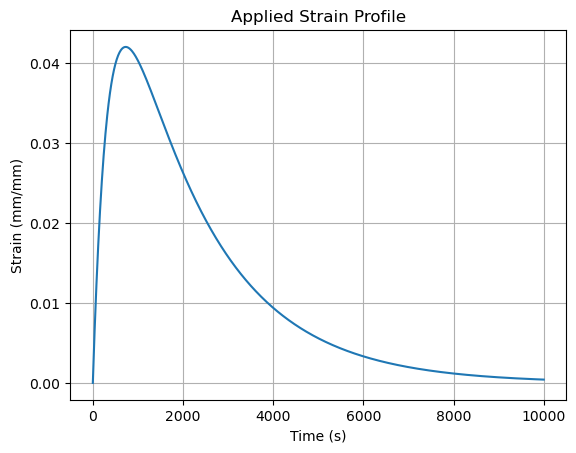

<Figure size 640x480 with 0 Axes>

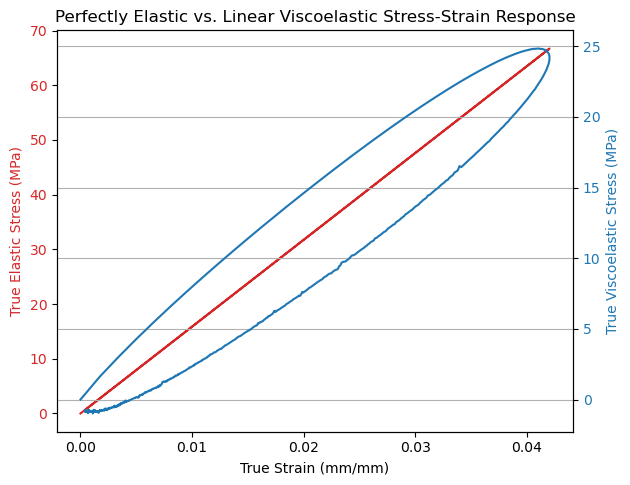

<Figure size 640x480 with 0 Axes>

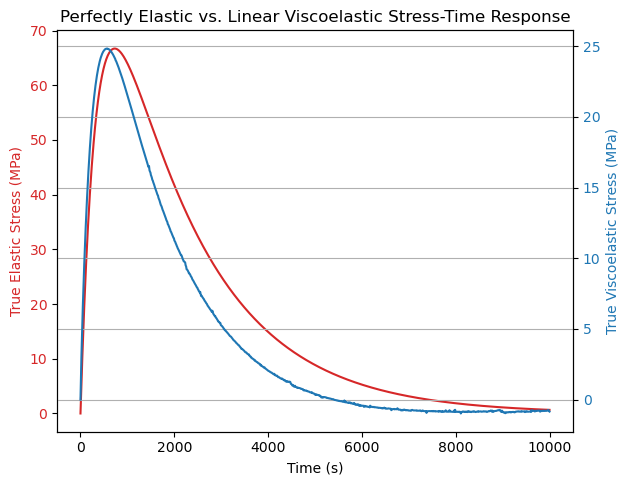

In [ ]:
#Plot applied strain profile
plt.figure(1)
plt.plot(t,delta_eps_th)
plt.title('Applied Strain Profile')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Strain (mm/mm)')
#plt.ylim([0,0.05])

dir = r'/Users/mikelapera/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/JHU/Research/morphing wing/final_writeup/data'
filename = 'applied_strain_history_thermal.csv'

# Save out applied strain history
with open(os.path.join(dir,filename),'w') as f:
    writer = csv.writer(f)
    writer.writerows(zip(t,delta_eps_th))

# Plot viscoelastic stress vs. strain response
plt.figure(2)

color = 'tab:red'
fig, ax1 = plt.subplots()
ax1.set_xlabel('True Strain (mm/mm)')
ax1.set_ylabel('True Elastic Stress (MPa)',color=color)
ax1.plot(delta_eps_th,E0*delta_eps_th,color=color)
ax1.tick_params(axis='y',labelcolor=color)

color = 'tab:blue'
ax2 = ax1.twinx()
ax2.set_xlabel('True Strain (mm/mm)')
ax2.set_ylabel('True Viscoelastic Stress (MPa)',color=color)
ax2.plot(delta_eps_th,stress,label='LVE',color=color)
ax2.tick_params(axis='y',labelcolor=color)
fig.tight_layout()
plt.grid(which='both')
plt.title('Perfectly Elastic vs. Linear Viscoelastic Stress-Strain Response')
plt.savefig('visco_elastic_stress_strain_comparison.png')
plt.savefig('visco_elastic_stress_strain_comparison.svg')
plt.show()

# Save out elastic solution
filename = 'elastic_stress_strain_thermal.csv'
with open(os.path.join(dir,filename),'w') as f:
    writer = csv.writer(f)
    writer.writerows(zip(delta_eps_th,E0*delta_eps_th))

# Save out viscoelastic solution
filename = 'visco_stress_strain_thermal.csv'
with open(os.path.join(dir,filename),'w') as f:
    writer = csv.writer(f)
    writer.writerows(zip(delta_eps_th,stress))

# Plot viscoelastic stress vs. time response
plt.figure(3)
color = 'tab:red'
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('True Elastic Stress (MPa)',color=color)
ax1.plot(t,E0*delta_eps_th,color=color)
ax1.tick_params(axis='y',labelcolor=color)

color = 'tab:blue'
ax2 = ax1.twinx()
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('True Viscoelastic Stress (MPa)',color=color)
ax2.plot(t,stress,label='LVE',color=color)
ax2.tick_params(axis='y',labelcolor=color)
fig.tight_layout()
plt.grid(which='both')
plt.title('Perfectly Elastic vs. Linear Viscoelastic Stress-Time Response')
plt.savefig('visco_elastic_stress_time_comparison.png')
plt.savefig('visco_elastic_stress_time_comparison.svg')
plt.show()

### BLOCK 10: Plot results (plotting w/o secondary axis)

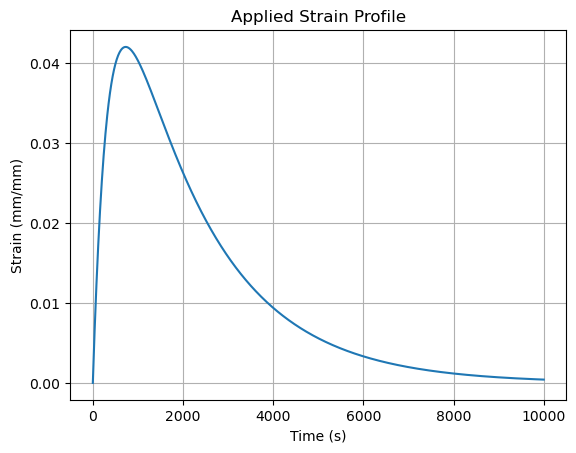

<Figure size 640x480 with 0 Axes>

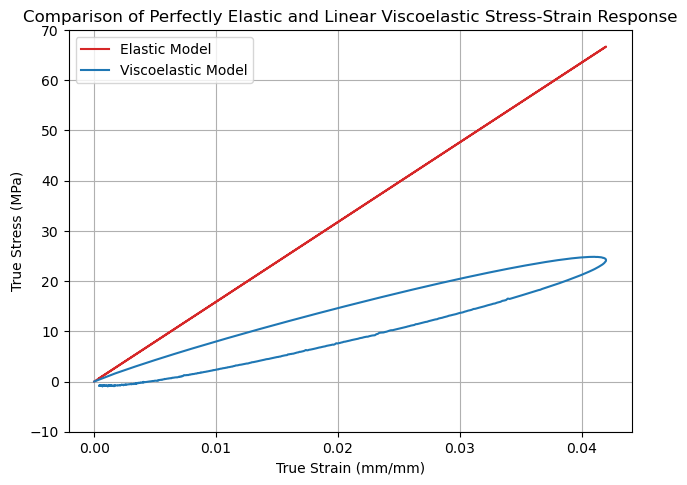

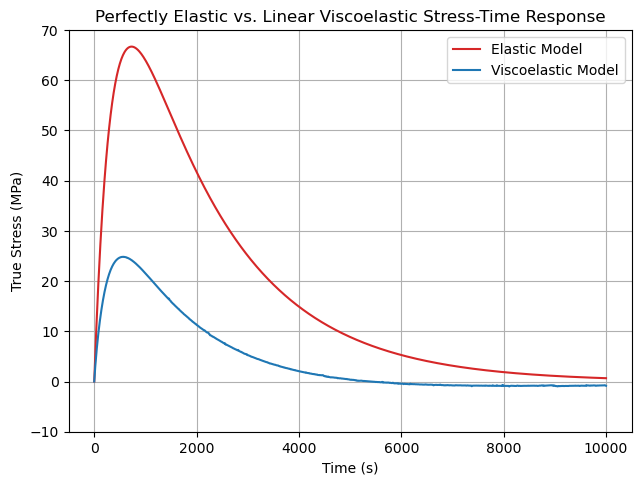

In [11]:
#Plot applied strain profile
plt.figure(1)
plt.plot(t,delta_eps_th)
plt.title('Applied Strain Profile')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Strain (mm/mm)')

# Plot viscoelastic stress vs. strain response
plt.figure(2)

color = 'tab:red'
fig, ax1 = plt.subplots()
ax1.set_xlabel('True Strain (mm/mm)')
ax1.set_ylabel('True Stress (MPa)')
ax1.plot(delta_eps_th,E0*delta_eps_th,color=color)
color = 'tab:blue'
ax1.plot(delta_eps_th,stress,label='LVE',color=color)
fig.tight_layout()
plt.grid(which='both')
plt.title('Comparison of Perfectly Elastic and Linear Viscoelastic Stress-Strain Response')
plt.ylim([-10,70])
plt.legend(['Elastic Model','Viscoelastic Model'])

# Plot viscoelastic stress vs. time response
plt.figure(3)
color = 'tab:red'
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('True Stress (MPa)')
ax1.plot(t,E0*delta_eps_th,color=color)
color = 'tab:blue'
ax1.plot(t,stress,label='LVE',color=color)
fig.tight_layout()
plt.grid(which='both')
plt.title('Perfectly Elastic vs. Linear Viscoelastic Stress-Time Response')
plt.ylim([-10,70])
plt.legend(['Elastic Model','Viscoelastic Model'])
plt.savefig('visco_elastic_stress_time_comparison_shared_axis.png')
plt.savefig('visco_elastic_stress_time_comparison_shared_axis.svg')
plt.show()

Text(0.5, 0, 'Time (s)')

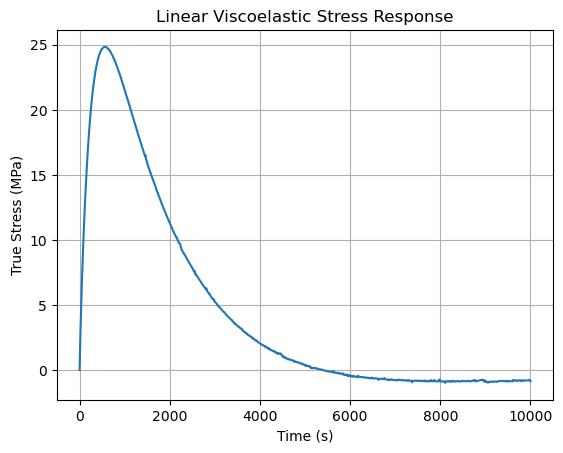

In [73]:
plt.figure()
plt.plot(t,stress,label='LVE')
plt.title('Linear Viscoelastic Stress Response')
plt.grid(which='both')
plt.ylabel('True Stress (MPa)')
plt.xlabel('Time (s)')

### BLOCK 11: Buckling "Crossover" Plots - Force vs. Time and Non-Dimensional Buckling Parameter ($\Pi$) vs. Time

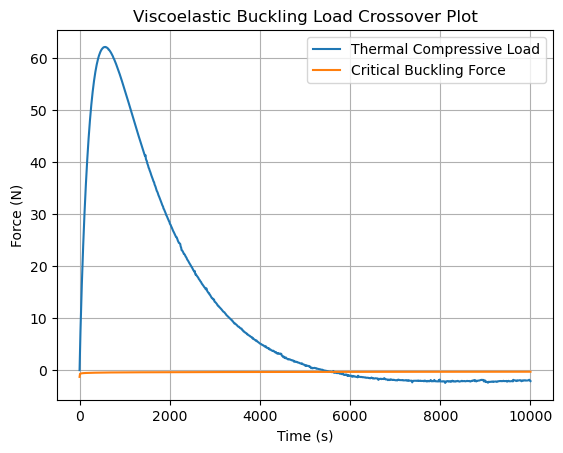

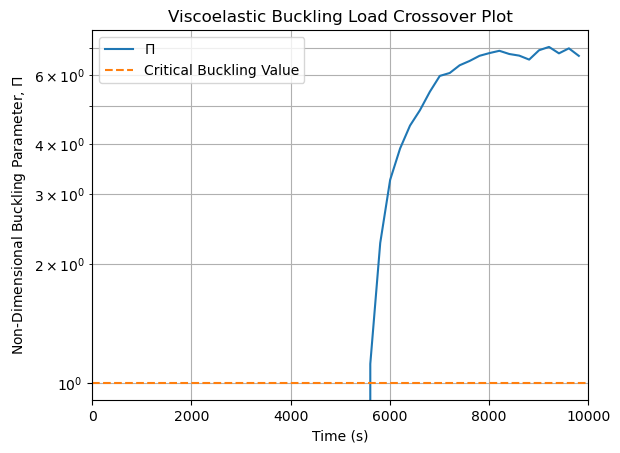

In [19]:
plt.figure(1)
plt.plot(t,stress * A_col)
plt.plot(t,Pcr)
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.legend(['Thermal Compressive Load','Critical Buckling Force'])
plt.title('Viscoelastic Buckling Load Crossover Plot')
#plt.xlim([0,1000])
#plt.ylim([0,-2])

sigma_cr = Pcr/A_col
PI = stress/sigma_cr

plt.figure(2)

# Downsample for plot cleanliness
tt   = t[0::20]
PIPI = PI[0::20]

plt.semilogy(tt,PIPI)
plt.semilogy([0,t_end],[1,1],'--')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel(r'Non-Dimensional Buckling Parameter, $\Pi$')
plt.title('Viscoelastic Buckling Load Crossover Plot')
plt.legend([r'$\Pi$','Critical Buckling Value'])
plt.xlim([0,10000])
plt.savefig('PI_buckling.png')
plt.savefig('PI_buckling.svg')

filename = 'PI_PARAMETER.csv'
# Save out applied strain history
with open(os.path.join(dir,filename),'w') as f:
    writer = csv.writer(f)
    writer.writerows(zip(tt,PIPI))

### BLOCK 12: Parametric Study of Different Cooling Profiles\ 
(See Overleaf Document Section 6 - https://www.overleaf.com/project/66a95568b58b8df1345ca7f2)

In [83]:
h = [0.001,0.005,0.01]           # convective heat transfer coefficient, mW/(mm^2*K)

### BLOCK 13: Solve LVE Stress
(See Overleaf Document Section 6 - https://www.overleaf.com/project/66a95568b58b8df1345ca7f2)

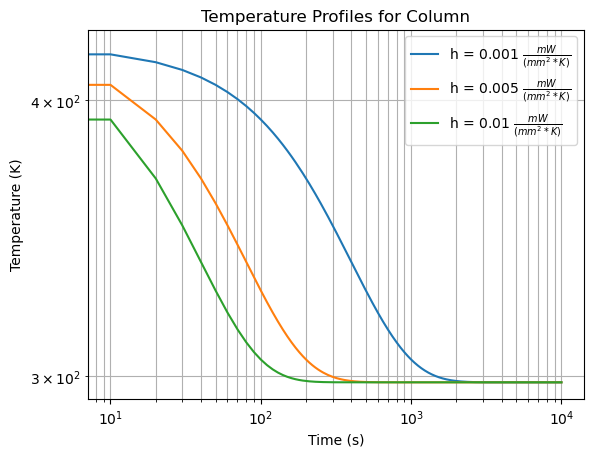

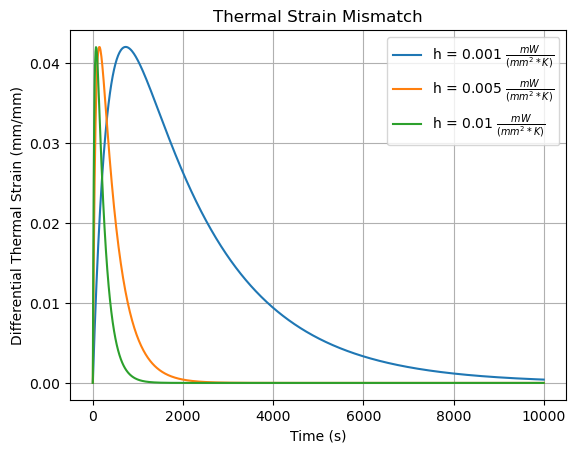

In [84]:
hleg = []
for hval in h:
    tau_c_col    = (m_col*cp)/(hval*Asurf_col)          # characteristic cooling time of column, s
    tau_c_frame  = (m_f*cp)/(hval*Asurf_f)

    # Calculate temperature profiles for frame and column
    Tcol         = calculateT(T0,Tinf,tau_c_col,t)
    Tframe       = calculateT(T0,Tinf,tau_c_frame,t)

    # Calculate thermal strains for frame and column
    eps_th_frame = calculate_eps_thermal(Tframe,Tinf,tau_c_frame)
    eps_th_col   = calculate_eps_thermal(Tcol,Tinf,tau_c_col)

    # Calculate thermal strain mismatch
    delta_eps_th = eps_th_frame - eps_th_col

    # Plotting
    plt.figure(1)
    plt.loglog(t,Tcol)
    plt.figure(2)
    plt.plot(t,delta_eps_th)
    hleg.append('h = ' + str(hval) + r' $\frac{mW}{(mm^2*K)}$')

plt.figure(1)   
plt.title('Temperature Profiles for Column')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)') 
plt.legend(hleg)
plt.figure(2)    
plt.title('Thermal Strain Mismatch')
plt.xlabel('Time (s)')
plt.ylabel('Differential Thermal Strain (mm/mm)')
plt.grid(which='both')
plt.legend(hleg)
plt.show()

/var/folders/h0/7w1kgmcj2bgc1t0rpbjm_hkc0000gn/T/ipykernel_99559/1837097005.py:46: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]
/var/folders/h0/7w1kgmcj2bgc1t0rpbjm_hkc0000gn/T/ipykernel_99559/1837097005.py:46: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]


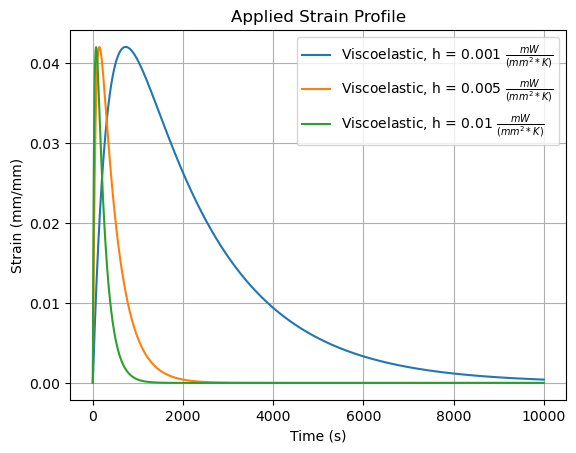

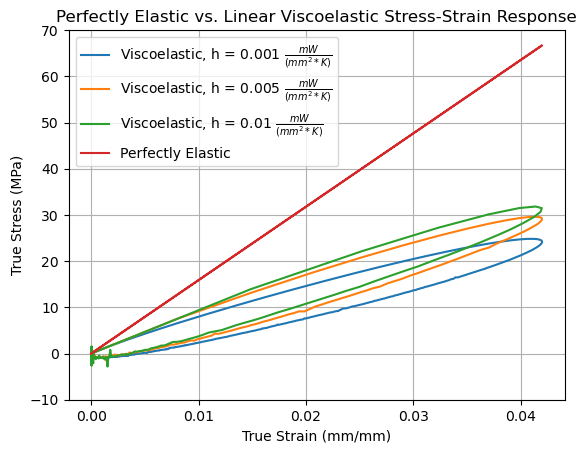

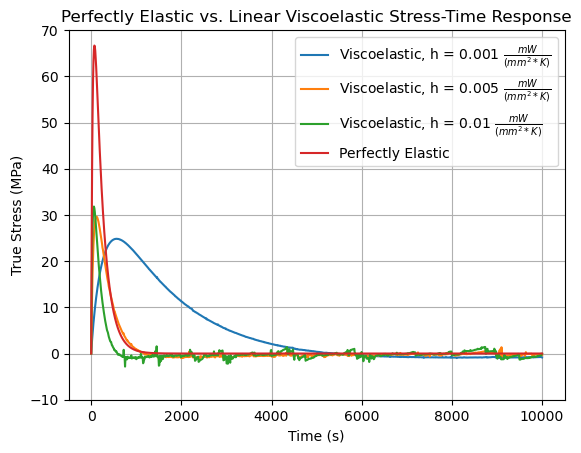

In [85]:
hleg  = []
hleg2 = []
hleg4 = []

for hval in h:
    tau_c_col    = (m_col*cp)/(hval*Asurf_col)          # characteristic cooling time of column, s
    tau_c_frame  = (m_f*cp)/(hval*Asurf_f)

    # Calculate temperature profiles for frame and column
    Tcol   = calculateT(T0,Tinf,tau_c_col,t)
    Tframe = calculateT(T0,Tinf,tau_c_frame,t)

    # Calculate thermal strains for frame and column
    eps_th_frame = calculate_eps_thermal(Tframe,Tinf,tau_c_frame)
    eps_th_col   = calculate_eps_thermal(Tcol,Tinf,tau_c_col)

    # Calculate thermal strain mismatch
    delta_eps_th = eps_th_frame - eps_th_col

    # Calculate LVE stress response
    stress = mat_LVE_PS(t,delta_eps_th,E0,ei,tau_i)

    hleg.append(str('Viscoelastic, h = ' + str(hval) + r' $\frac{mW}{(mm^2*K)}$'))

    #Plot applied strain profile
    plt.figure(1)
    plt.plot(t,delta_eps_th)

    # Plot viscoelastic stress vs. strain response
    plt.figure(2)
    plt.plot(delta_eps_th,stress)
 
    # Plot viscoelastic stress vs. time response
    plt.figure(3)
    plt.plot(t,stress)


plt.figure(1)
plt.title('Applied Strain Profile')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Strain (mm/mm)')
plt.legend(hleg)

hleg2 = hleg
hleg2.append('Perfectly Elastic')
plt.figure(2)
plt.plot(delta_eps_th,E0*delta_eps_th)
plt.grid(which='both')
plt.title('Perfectly Elastic vs. Linear Viscoelastic Stress-Strain Response')
plt.xlabel('True Strain (mm/mm)')
plt.ylabel('True Stress (MPa)')  
plt.ylim([-10,70])
plt.legend(hleg2)
plt.savefig('visco_elastic_stress_strain_sweep.png')
plt.savefig('visco_elastic_stress_strain_sweep.svg')

plt.figure(3)
plt.plot(t,E0*delta_eps_th)
plt.grid(which='both')
plt.title('Perfectly Elastic vs. Linear Viscoelastic Stress-Time Response')
plt.xlabel('Time (s)')
plt.ylabel('True Stress (MPa)')
plt.ylim([-10,70])
plt.legend(hleg)
plt.savefig('visco_elastic_stress_time_sweep.png')
plt.savefig('visco_elastic_stress_time_sweep.svg')


plt.show()

### ### BLOCK 13: Plot critical buckling parameter crossover plot for multiple cooling profiles\
(See Overleaf Document Section 6 - https://www.overleaf.com/project/66a95568b58b8df1345ca7f2)

/var/folders/h0/7w1kgmcj2bgc1t0rpbjm_hkc0000gn/T/ipykernel_99559/1837097005.py:46: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]
/var/folders/h0/7w1kgmcj2bgc1t0rpbjm_hkc0000gn/T/ipykernel_99559/1837097005.py:46: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  stressVec[i] = quad(integrand_PS,0.0,tmax,args=(tmax,timeVec,strainVec,E0,ei,tau_i))[0]


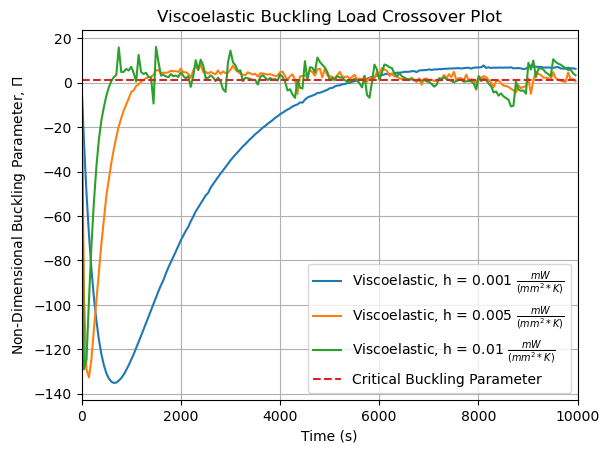

In [86]:
hleg  = []
hleg2 = []
hleg4 = []

for hval in h:
    tau_c_col    = (m_col*cp)/(hval*Asurf_col)          # characteristic cooling time of column, s
    tau_c_frame  = (m_f*cp)/(hval*Asurf_f)

    # Calculate temperature profiles for frame and column
    Tcol   = calculateT(T0,Tinf,tau_c_col,t)
    Tframe = calculateT(T0,Tinf,tau_c_frame,t)

    # Calculate thermal strains for frame and column
    eps_th_frame = calculate_eps_thermal(Tframe,Tinf,tau_c_frame)
    eps_th_col   = calculate_eps_thermal(Tcol,Tinf,tau_c_col)

    # Calculate thermal strain mismatch
    delta_eps_th = eps_th_frame - eps_th_col

    # Calculate LVE stress response
    stress = mat_LVE_PS(t,delta_eps_th,E0,ei,tau_i)

    hleg.append(str('Viscoelastic, h = ' + str(hval) + r' $\frac{mW}{(mm^2*K)}$'))

    # Plot non-dimensional buckling parameter
    Pcr,_,_ = Pcritical_PS(T0,Tinf,Tref,Icol,kc,Lcol,tau_c_frame,t)
    sigma_cr = Pcr/A_col
    PI = stress/sigma_cr

    # Downsample for plot cleanliness
    plt.figure(1)    
    plt.plot(t[0::5],PI[0::5])


hleg.append('Critical Buckling Parameter')
plt.figure(1)
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel(r'Non-Dimensional Buckling Parameter, $\Pi$')
plt.title('Viscoelastic Buckling Load Crossover Plot')
plt.plot([0,t_end],[1,1],'--')
plt.xlim([0,10000])
plt.legend(hleg)
plt.savefig('PI_buckling_sweep.png')
plt.savefig('PI_buckling_sweep.svg')


## ---- DO NOT USE ----

To calculate the characteristic relaxation time $\tau_{visco}$, we use the following definitions:
$$
\tau_{visco} = \frac{\eta}{\mu_{neq}}
$$
$$
E_{neq} = E_{total} - E_{eq} = E_0 - E_{\infty}
$$
where:
$$
E_{neq} = 2\mu_{neq}(1+\nu_g)
$$
Therefore:
$$ 
\tau_{visco} = \frac{2\eta(1+\nu_g)}{E_{neq}} = \frac{2\eta(1+\nu_g)}{E_{total} - E_{eq}}
$$

Effective viscosity = 3615.89 MPa*s
Characteristic relaxation time = 6.17 sec


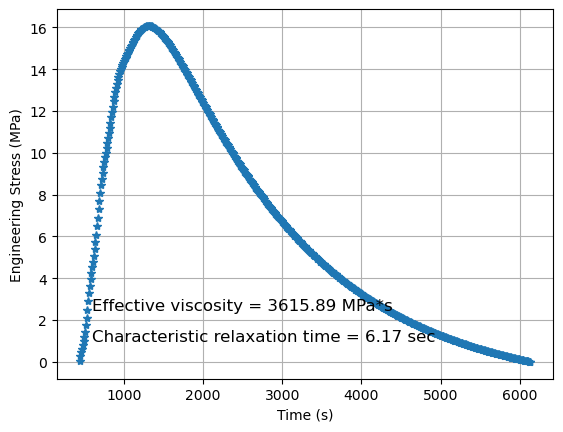

In [8]:
# Find time domain and Pth values which exceed theoretical buckling value
fcrit = np.asarray(sorted(i for i in sigma_th if i >= np.mean(sigma_cr))) #using mean for simplicity - all values in Pcr are nearly identical

# Locate overlap by sorting where Pth > Pcrit
sorter = np.argsort(sigma_th)
# print("index of first occurrence of each value: ", 
#       sorter[np.searchsorted(Pth, fcrit, sorter=sorter)])
idx = sorter[np.searchsorted(sigma_th, fcrit, sorter=sorter)]
plt.loglog(t[idx],sigma_th[idx],'*')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Engineering Stress (MPa)')
eta_approx = trapezoid(sigma_th[idx])
print(eta_approx)

# Shift points down to approx. y = 0 to use trapezoidal rule
bb=sigma_th[idx]-min(sigma_th[idx])
plt.plot(t[idx],bb,'*')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Engineering Stress (MPa)')
eta_approx = trapezoid(bb)
print('Effective viscosity = ' + "{:.2f}".format(eta_approx) + ' MPa*s')
print('Characteristic relaxation time' + ' = ' + str(round((2*eta_approx*(1+nu_g))/(E0-E_eq),2)) + ' sec')
plt.text(600, 2.5, 'Effective viscosity = ' + "{:.2f}".format(eta_approx) + ' MPa*s', fontsize =12)
plt.text(600, 1, 'Characteristic relaxation time' + ' = ' + str(round((2*eta_approx*(1+nu_g))/(E0-E_eq),2)) + ' sec',fontsize=12)
plt.show()

### Consider Thermoelastic Case (solely temperature dependent)

In [34]:
# Slowest DMA (1Hz) Data - Phrozen
phrozen_1hz_Estorage = np.array([1.26E+03,
1.08E+03,
8.98E+02,
7.31E+02,
6.26E+02,
5.30E+02,
4.47E+02,
3.62E+02,
2.91E+02,
2.32E+02,
1.73E+02,
1.26E+02,
7.20E+01,
4.75E+01,
3.37E+01,
2.45E+01,
1.62E+01,
1.32E+01,
5.60E+00,
6.03E+00,
4.12E+00,
1.74E+00])
phrozen_1hz_temp = np.array([3.05E+02,
3.10E+02,
3.15E+02,
3.20E+02,
3.25E+02,
3.30E+02,
3.35E+02,
3.40E+02,
3.45E+02,
3.51E+02,
3.56E+02,
3.61E+02,
3.66E+02,
3.71E+02,
3.76E+02,
3.81E+02,
3.87E+02,
3.92E+02,
3.97E+02,
4.02E+02,
4.07E+02,
4.12E+02])

In [215]:
# Calculate temperature-dependent Young's modulus from 1Hz DMA data
def calculate_ET_DMA(T):
    E_T = np.interp(T,phrozen_1hz_temp,phrozen_1hz_Estorage)
    return E_T

# Calculate temperature-dependent Young's modulus (for pure elasticity case) - fictitious thermoelastic relationship
def calculate_ET(E0,T,T0,Tref):
    E_T = E0 - 0.9*E0*((T-Tref)/(T0-Tref))
    return E_T

# Calculate CTE value at given temperature
def calculate_CTE(T):
    CTE_val = np.interp(T,CTE[0],CTE[1])
    return CTE_val 

# Calculate thermally-driven buckling load (for pure elasticity case)
def Pthermal_elastic(A,C1,C2,t,T0,Tinf,tau_c_col,tau_c_frame):
    _ , T   = calculate_alpha(C1,C2,T0,Tref,tau_c_col,t)
    CTE_val = np.interp(T,CTE[0],CTE[1])
    #E_T     = calculate_ET(E0,T,T0,Tref)
    E_T     = calculate_ET_DMA(T)
    Pth     = CTE_val * A * E_T * (T0-Tinf) * (np.exp(-t/tau_c_frame) - np.exp(-t/tau_c_col))
    return Pth, E_T, T

# Calculate critical buckling load (for pure elasticity case)
def Pcritical_elastic(T0,Tinf,Tref,Icol,k,Lcol,tau_c_frame,t):
    _ , T = calculate_alpha(C1,C2,T0,Tref,tau_c_col,t)
    #E_T    = calculate_ET(E0,T,T0,Tref)
    CTE_val = np.interp(T,CTE[0],CTE[1])
    E_T   = calculate_ET_DMA(T)
    Leff  = kc * (Lcol + CTE_val*(np.exp(-t/tau_c_frame)*(T0-Tinf) + Tinf - Tref))
    Pcr   = -1 * (np.pi**2 * E_T * Icol) / (Leff**2)
    return Pcr


# Recalculate thermally-driven compressive and critical buckling loads
Pth, E_T, T = Pthermal_elastic(A_col,C1,C2,t,T0,Tinf,tau_c_col,tau_c_frame)
Pcr         = Pcritical_elastic(T0,Tinf,Tref,Icol,k,Lcol,tau_c_frame,t)

plt.figure(1)
plt.plot(t,Pth)
plt.plot(t,Pcr)
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.legend(['Thermal Compressive Load','Critical Buckling Force'])
plt.title('Elastic Buckling Load Crossover Plot')

plt.figure(2)
plt.plot(t,E_T)
plt.xlabel('Time (s)')
plt.ylabel('Column Elastic Modulus (MPa)')
plt.grid(which='both')

plt.figure(3)
plt.plot(T,E_T)
plt.xlabel('Temperature (K)')
plt.ylabel('Column Elastic Modulus (MPa)')
plt.grid(which='both')

NameError: name 'phrozen_1hz_temp' is not defined

### Plot dimensionless buckling force parameter, $\beta = \frac{P_{th}}{P_{cr}}$

0.001


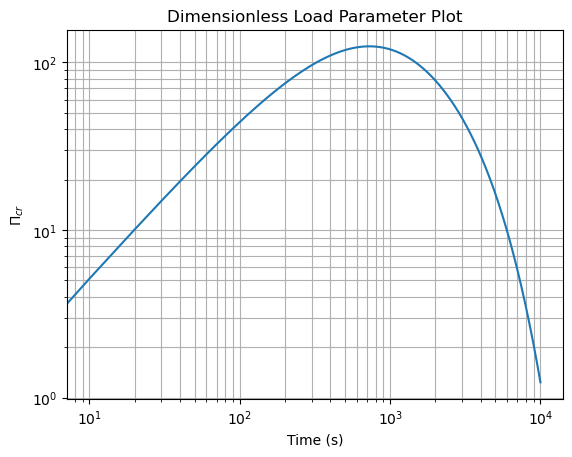

In [19]:
PI = np.abs(Pth)/Pcr
plt.loglog(t,PI)
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel(r'$\Pi_{cr}$')
plt.title('Dimensionless Load Parameter Plot')
#plt.xlim([0,1000])
#plt.ylim([0,-2])
print(h)

### Identify $\Pi_{cr}=1$ intersection points for plotting

In [214]:
PI = np.abs(Pth)/Pcr
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
# Find max 
idx2 = find_nearest(PI,PI.max())

PI_low = PI[0:idx2]
PI_high = PI[idx2+1:-1]
idx1 = find_nearest(PI_low,value=1)
idx3 = find_nearest(PI_high,value=1) + idx2 + 1
# +1 to include include intercept point
PI_low = PI[0:idx1+1]
t_low = t[0:idx1+1]
# +1 to include include intercept point
PI_mid = PI[idx1:idx3+1]
t_mid = t[idx1:idx3+1]
PI_high = PI[idx3:-1]
t_high = t[idx3:-1]

plt.loglog(t_low,PI_low,'-b')
plt.loglog(t_mid,PI_mid,'--b')
plt.loglog(t_high,PI_high,'-b')
plt.loglog(t[idx1],PI[idx1],'x',color='red')
plt.loglog(t[idx3],PI[idx3],'x',color='red')
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel(r'$\Pi_{cr}$')
plt.title('Dimensionless Load Parameter Plot')
plt.show()


ValueError: attempt to get argmin of an empty sequence

[0 1]
